# 📚 AI Payroll Guardian — Payroll & Compliance RAG Knowledge System (Phase 5)
**Project**: AI Payroll Guardian  
**Phase**: Phase 5 — Authoritative Compliance Retrieval & Knowledge Grounding  
**Goal**: Ground detected payroll anomalies in authoritative statutory regulations and internal organizational policies with strict versioning, jurisdiction checking, and date applicability filtering.

---
### 📌 Scope of Analysis
1. **Knowledge Corpus Registry & Authority Tier Distribution**
2. **Structural Semantic Chunking Telemetry**
3. **Date- and Jurisdiction-Aware Hybrid Retrieval**
4. **Retrieval Evaluation Metrics (Recall@K, MRR, Authority Accuracy)**
5. **Negative Query Constraint Verification**
6. **End-to-End Evidence Card $ightarrow$ Knowledge Grounding Integration**
7. **Traceable Citations & Audit Footnotes**


## 1. Ingest Knowledge Registry & Vector Store


In [1]:
import sys
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 10

ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from rag.ingestion.document_registry import DocumentRegistry
from rag.retrieval.vector_store import PayrollVectorStore
from rag.retrieval.retriever import PayrollRAGRetriever
from rag.embeddings.embeddings import TFIDFEmbeddingProvider
from rag.retrieval.reranker import AuthorityAwareReranker
from rag.metadata import Jurisdiction, Topic

reg = DocumentRegistry(ROOT_DIR / "data" / "knowledge" / "metadata" / "registry.json")
v_store = PayrollVectorStore.load(ROOT_DIR / "data" / "knowledge" / "embeddings")

print(f"Loaded Knowledge Registry: {len(reg.documents)} registered documents.")
print(f"Loaded Vector Store     : {len(v_store.chunks_metadata)} semantic chunks (Dim={v_store.embedding_dimension}).")



Loaded Knowledge Registry: 8 registered documents.
Loaded Vector Store     : 40 semantic chunks (Dim=256).


## 2. Document Registry by Authority Tier & Jurisdiction


,Document ID,Title,Authority Tier,Jurisdiction,Topic,Effective From,Effective Until,Version
0,COMPANY_OVERTIME_BONUS_POLICY_2024,Company Global Overtime and Bonus Policy 2024,COMPANY_POLICY,INDIA,OVERTIME,2024-01-01,CURRENT,v1.2
1,COMPANY_LEAVE_ATTENDANCE_POLICY_2024,Company Leave and Attendance Policy 2024,COMPANY_POLICY,INDIA,LEAVE,2024-01-01,CURRENT,v1.0
2,EPFO_ACT_1952,EPFO Employees Provident Funds Act 1952,AUTHORITATIVE,INDIA,PAYROLL_PROCESSING,1952-11-01,CURRENT,v2.4
3,EPFO_HISTORICAL_NOTIFICATION_2014,EPFO Historical Notification 2014 Wage Ceiling,AUTHORITATIVE,INDIA,PF,2014-09-01,2023-12-31,v1.0-HISTORICAL
4,ESIC_ACT_1948,ESIC Employees State Insurance Act 1948,AUTHORITATIVE,INDIA,PAYROLL_PROCESSING,2019-07-01,CURRENT,v3.1
5,INCOME_TAX_SEC_192,Income Tax Act 1961 Section 192 TDS,AUTHORITATIVE,INDIA,PAYROLL_PROCESSING,2023-04-01,CURRENT,v4.0
6,KARNATAKA_PT_ACT_1976,Karnataka Tax on Professions Act 1976,AUTHORITATIVE,KARNATAKA,PROFESSIONAL_TAX,2023-04-01,CURRENT,v2.0
7,MAHARASHTRA_PT_ACT_1975,Maharashtra State Professional Tax Act 1975,AUTHORITATIVE,MAHARASHTRA,PROFESSIONAL_TAX,2023-04-01,CURRENT,v2.2


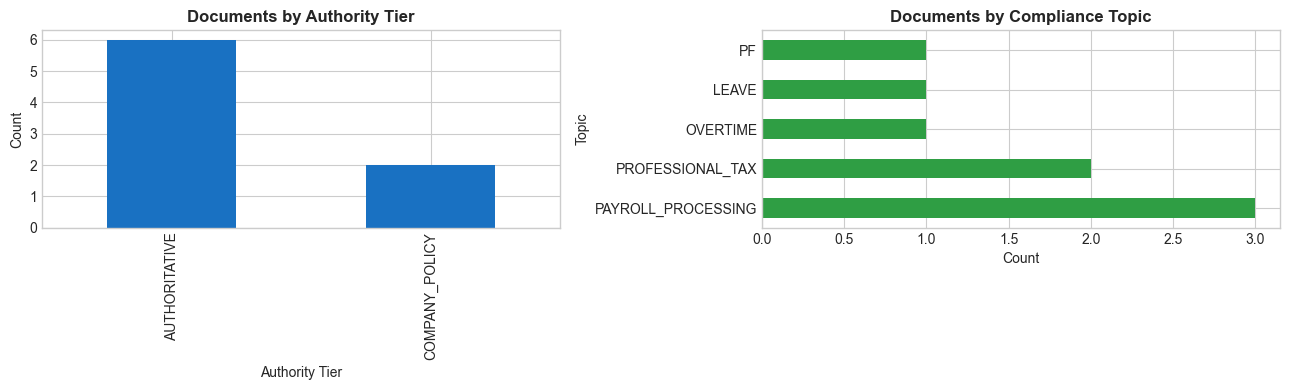

In [2]:
doc_data = []
for doc in reg.documents.values():
    doc_data.append({
        "Document ID": doc.document_id,
        "Title": doc.title,
        "Authority Tier": doc.authority_level.value,
        "Jurisdiction": doc.jurisdiction.value,
        "Topic": doc.topic.value,
        "Effective From": doc.effective_from,
        "Effective Until": doc.effective_until or "CURRENT",
        "Version": doc.document_version,
    })

doc_df = pd.DataFrame(doc_data)
display(doc_df)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
doc_df["Authority Tier"].value_counts().plot(kind="bar", ax=ax1, color="#1971c2")
ax1.set_title("Documents by Authority Tier", fontweight="bold")
ax1.set_ylabel("Count")

doc_df["Topic"].value_counts().plot(kind="barh", ax=ax2, color="#2f9e44")
ax2.set_title("Documents by Compliance Topic", fontweight="bold")
ax2.set_xlabel("Count")

plt.tight_layout()
plt.show()



## 3. Structural Semantic Chunk Distribution


,Chunk ID,Document ID,Section,Char Count,Token Count
0,COMPANY_OVERTIME_BONUS_POLICY_2024_CH_000,COMPANY_OVERTIME_BONUS_POLICY_2024,General Overview,587,68
1,COMPANY_OVERTIME_BONUS_POLICY_2024_CH_001,COMPANY_OVERTIME_BONUS_POLICY_2024,1. Eligibility for Overtime,465,62
2,COMPANY_OVERTIME_BONUS_POLICY_2024_CH_002,COMPANY_OVERTIME_BONUS_POLICY_2024,2. Overtime Rate Calculation Formula,521,70
3,COMPANY_OVERTIME_BONUS_POLICY_2024_CH_003,COMPANY_OVERTIME_BONUS_POLICY_2024,3. Monthly Overtime Cap,375,53
4,COMPANY_OVERTIME_BONUS_POLICY_2024_CH_004,COMPANY_OVERTIME_BONUS_POLICY_2024,1. Festive Diwali Bonus (October Cycle),335,50
5,COMPANY_OVERTIME_BONUS_POLICY_2024_CH_005,COMPANY_OVERTIME_BONUS_POLICY_2024,2. Annual Performance Appraisal Bonus (March Cycle),374,53
6,COMPANY_OVERTIME_BONUS_POLICY_2024_CH_006,COMPANY_OVERTIME_BONUS_POLICY_2024,3. Out-of-Cycle Discretionary Bonuses,339,46
7,COMPANY_LEAVE_ATTENDANCE_POLICY_2024_CH_000,COMPANY_LEAVE_ATTENDANCE_POLICY_2024,General Overview,515,59
8,COMPANY_LEAVE_ATTENDANCE_POLICY_2024_CH_001,COMPANY_LEAVE_ATTENDANCE_POLICY_2024,1. Monthly Working Days Definition,607,81
9,COMPANY_LEAVE_ATTENDANCE_POLICY_2024_CH_002,COMPANY_LEAVE_ATTENDANCE_POLICY_2024,1. Gross Salary Formula,385,45


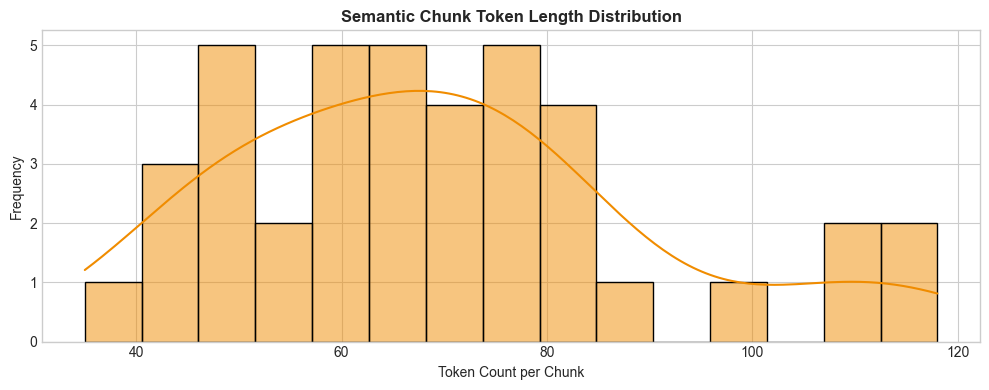

In [3]:
chunk_data = []
for m, text in zip(v_store.chunks_metadata, v_store.chunks_text):
    chunk_data.append({
        "Chunk ID": m.chunk_id,
        "Document ID": m.document_id,
        "Section": m.section,
        "Char Count": m.char_count,
        "Token Count": m.token_count,
    })

chunk_df = pd.DataFrame(chunk_data)
display(chunk_df.head(10))

plt.figure(figsize=(10, 4))
sns.histplot(chunk_df["Token Count"], bins=15, kde=True, color="#f08c00")
plt.title("Semantic Chunk Token Length Distribution", fontweight="bold")
plt.xlabel("Token Count per Chunk")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()



## 4. Benchmark Retrieval Evaluation Results (Ground Truth Queries)


In [4]:
with open(ROOT_DIR / "data" / "knowledge" / "metadata" / "rag_eval_results.json", "r") as f:
    eval_data = json.load(f)

metrics_table = pd.DataFrame([
    {"Metric": "Recall@1", "Value": f"{eval_data['recall_at_1']*100:.1f}%"},
    {"Metric": "Recall@3", "Value": f"{eval_data['recall_at_3']*100:.1f}%"},
    {"Metric": "Recall@5", "Value": f"{eval_data['recall_at_5']*100:.1f}%"},
    {"Metric": "Mean Reciprocal Rank (MRR)", "Value": f"{eval_data['mrr']:.4f}"},
    {"Metric": "Authority Tier Accuracy", "Value": f"{eval_data['authority_accuracy']*100:.1f}%"},
    {"Metric": "Jurisdiction Accuracy", "Value": f"{eval_data['jurisdiction_accuracy']*100:.1f}%"},
    {"Metric": "Date Applicability Accuracy", "Value": f"{eval_data['date_applicability_accuracy']*100:.1f}%"},
    {"Metric": "Negative Constraint Pass Rate", "Value": f"{eval_data['negative_test_pass_rate']*100:.1f}%"},
])
display(metrics_table)



,Metric,Value
0,Recall@1,100.0%
1,Recall@3,100.0%
2,Recall@5,100.0%
3,Mean Reciprocal Rank (MRR),1.0000
4,Authority Tier Accuracy,100.0%
5,Jurisdiction Accuracy,100.0%
6,Date Applicability Accuracy,100.0%
7,Negative Constraint Pass Rate,100.0%


## 5. End-to-End Evidence Card to Regulatory Knowledge Retrieval


In [5]:
emb_provider = TFIDFEmbeddingProvider(max_features=256)
emb_provider.fit(v_store.chunks_text)
reranker = AuthorityAwareReranker()
retriever = PayrollRAGRetriever(v_store, emb_provider, reranker)

with open(ROOT_DIR / 'models' / 'v2' / 'sample_evidence_v2.json', 'r') as f:
    sample_evidence = json.load(f)

resp = retriever.retrieve_for_evidence_card(sample_evidence, top_n=2)

print('=== INPUT EVIDENCE CARD ===')
print('Employee ID    :', sample_evidence.get('employee_id'))
print('Anomaly Types  :', sample_evidence.get('anomaly_types'))
print('Rule Violations:', sample_evidence.get('rule_violations'))
print('Payroll Month  :', sample_evidence.get('payroll_month'))

print('\n=== RAG RETRIEVAL RESULT ===')
print('Generated Query:', resp.query)
print('Jurisdiction   :', resp.jurisdiction.value)
print('Status         :', resp.status)

for i, r in enumerate(resp.results, 1):
    print(f'\n[Result {i}] {r.title} ({r.authority_level.value})')
    print(f'  Citation  : {r.citation}')
    print(f'  Section   : {r.section}')
    print(f'  Relevance : {r.rerank_score*100:.1f}%')
    print(f'  Excerpt   : {r.text[:220]}...')



=== INPUT EVIDENCE CARD ===
Employee ID    : EMP0001042
Anomaly Types  : ['SUBTLE_PF_MISMATCH']
Rule Violations: []
Payroll Month  : 2024-09
=== RAG RETRIEVAL RESULT ===
Generated Query: EPFO Provident Fund statutory 12 percent basic wage contribution ceiling calculation
Jurisdiction   : INDIA
Status         : SUCCESS
[Result 1] EPFO Employees Provident Funds Act 1952 (AUTHORITATIVE)
  Citation  : [EPFO_ACT_1952, Section: 3. Statutory Wage Ceiling Threshold, Version: v2.4, Jurisdiction: INDIA, Effective: 1952-11-01 to CURRENT]
  Section   : 3. Statutory Wage Ceiling Threshold
  Relevance : 68.8%
  Excerpt   : [Employees' Provident Fund Organisation (EPFO), Ministry of Labour and Employment, Government of India | EPFO Employees Provident Funds Act 1952 | 3. Statutory Wage Ceiling Threshold]
The statutory wage ceiling for manda...
[Result 2] EPFO Employees Provident Funds Act 1952 (AUTHORITATIVE)
  Citation  : [EPFO_ACT_1952, Section: 2. Breakdown of Employer's Statutory Contribution, Ve